# Module 3: Logistic Regression

In this assignment, you will
- explore the sigmoid function (also known as the logistic function)
- explore logistic regression; which uses the sigmoid function

In [3]:
import numpy as np
import matplotlib.pyplot as plt
#from utils import plot_data


## Sigmoid or Logistic Function
As discussed in the lecture videos, for a classification task, we can start by using our linear regression model, $h(\mathbf{x}^{(i)}) = \mathbf{w} \cdot  \mathbf{x}^{(i)} + b$, to predict $y$ given $x$.
- However, we would like the predictions of our classification model to be between 0 and 1 since our output variable $y$ is either 0 or 1.
- This can be accomplished by using a "sigmoid function" which maps all input values to values between 0 and 1.


Let's implement the sigmoid function and see this for ourselves.

## Formula for Sigmoid function

The formula for a sigmoid function is as follows -  

$g(z) = \frac{1}{1+e^{-z}}\tag{1}$

In the case of logistic regression, z (the input to the sigmoid function), is the output of a linear regression model.
- In the case of a single example, $z$ is scalar.
- in the case of multiple examples, $z$ may be a vector consisting of $m$ values, one for each example.
- The implementation of the sigmoid function should cover both of these potential input formats.
Let's implement this in Python.

NumPy has a function called [`exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html), which offers a convenient way to calculate the exponential ( $e^{z}$) of all elements in the input array (`z`).

It also works with a single number as an input, as shown below.

In [4]:
# Input is an array.
input_array = np.array([1,2,3])
exp_array = np.exp(input_array)

print("Input to exp:", input_array)
print("Output of exp:", exp_array)

# Input is a single number
input_val = 1
exp_val = np.exp(input_val)

print("Input to exp:", input_val)
print("Output of exp:", exp_val)

Input to exp: [1 2 3]
Output of exp: [ 2.71828183  7.3890561  20.08553692]
Input to exp: 1
Output of exp: 2.718281828459045


The `sigmoid` function is implemented in python as shown in the cell below.

In [6]:
def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z

    """
    #####################################
    # WRITE THE SIGMOID FUNCTION HERE
    g = 1 / (1 + np.exp(-z))
    

    #####################################

    return g

Let's see what the output of this function is for various value of `z`

In [7]:
# Generate an array of evenly spaced values between -10 and 10
z_tmp = np.arange(-10,11)

# Use the function implemented above to get the sigmoid values
y = sigmoid(z_tmp)

# Code for pretty printing the two arrays next to each other
np.set_printoptions(precision=3)
print("Input (z), Output (sigmoid(z))")
print(np.c_[z_tmp, y])

Input (z), Output (sigmoid(z))
[[-1.000e+01  4.540e-05]
 [-9.000e+00  1.234e-04]
 [-8.000e+00  3.354e-04]
 [-7.000e+00  9.111e-04]
 [-6.000e+00  2.473e-03]
 [-5.000e+00  6.693e-03]
 [-4.000e+00  1.799e-02]
 [-3.000e+00  4.743e-02]
 [-2.000e+00  1.192e-01]
 [-1.000e+00  2.689e-01]
 [ 0.000e+00  5.000e-01]
 [ 1.000e+00  7.311e-01]
 [ 2.000e+00  8.808e-01]
 [ 3.000e+00  9.526e-01]
 [ 4.000e+00  9.820e-01]
 [ 5.000e+00  9.933e-01]
 [ 6.000e+00  9.975e-01]
 [ 7.000e+00  9.991e-01]
 [ 8.000e+00  9.997e-01]
 [ 9.000e+00  9.999e-01]
 [ 1.000e+01  1.000e+00]]


The values in the left column are `z`, and the values in the right column are `sigmoid(z)`. As you can see, the input values to the sigmoid range from -10 to 10, and the output values range from 0 to 1.

Now, let's try to plot this function using the `matplotlib` library.

Text(0.5, 0, 'z')

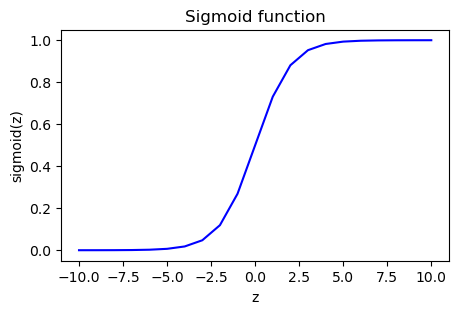

In [8]:
# Plot z vs sigmoid(z)
fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(z_tmp, y, c="b")

ax.set_title("Sigmoid function")
ax.set_ylabel('sigmoid(z)')
ax.set_xlabel('z')

As you can see, the sigmoid function approaches  `0` as `z` goes to large negative values and approaches `1` as `z` goes to large positive values.


In [9]:
def plot_data(X, y, ax):

    y = y.ravel()   # Convert (m,1) -> (m,)

    pos = y == 1
    neg = y == 0

    ax.scatter(X[pos, 0], X[pos, 1],
               marker='x', c='red', label='y=1')

    ax.scatter(X[neg, 0], X[neg, 1],
               marker='o', c='blue', label='y=0')

    ax.legend()

## Decision Boundary
 Lets the decision boundary for a logistic regression model. This will give you a better sense of what the model is predicting.



Let's suppose you have following training dataset

*   The input variable X is a numpy array which has 6 training examples, each with two features
*   The output variable y is also a numpy array with 6 examples, and y is either 0 or 1

In [10]:
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1]).reshape(-1,1)

### Logistic regression model


* Suppose you'd like to train a logistic regression model on this data which has the form   

  $h(x) = g(w_0x_0+w_1x_1 + b)$
  
  where $g(z) = \frac{1}{1+e^{-z}}$, which is the sigmoid function


* Let's say that you trained the model and get the parameters as $b = -3, w_0 = 1, w_1 = 1$. That is,

  $h(x) = g(x_0+x_1-3)$

  (You'll learn how to train/fit and get these parameters in the further sections)
  
  
Let's try to understand what this trained model is predicting by plotting its decision boundary

* Recall that for logistic regression, the model is represented as

  $$h(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x}^{(i)} + b) \tag{1}$$

  where $g(z)$ is known as the sigmoid function and it maps all input values to values between 0 and 1:

  $g(z) = \frac{1}{1+e^{-z}}\tag{2}$
  and $\mathbf{w} \cdot \mathbf{x}$ is the vector dot product:
  
  $$\mathbf{w} \cdot \mathbf{x} = w_0 x_0 + w_1 x_1$$
  
  
 * We interpret the output of the model ($h(x)$) as the probability that $y=1$ given $\mathbf{x}$ and parameterized by $\mathbf{w}$ and $b$.
* Therefore, to get a final prediction ($y=0$ or $y=1$) from the logistic regression model, we can use the following heuristic -

  if $h(x) >= 0.5$, predict $y=1$
  
  if $h(x) < 0.5$, predict $y=0$
  
  
* Let's plot the sigmoid function to see where $g(z) >= 0.5$

## Plotting decision boundary

Now, let's go back to our example to understand how the logistic regression model is making predictions.

* Our logistic regression model has the form

  $h(\mathbf{x}) = g(-3 + x_0+x_1)$


* From what you've learnt above, you can see that this model predicts $y=1$ if $-3 + x_0+x_1 >= 0$

Let's see what this looks like graphically. We'll start by plotting $-3 + x_0+x_1 = 0$, which is equivalent to $x_1 = 3 - x_0$.

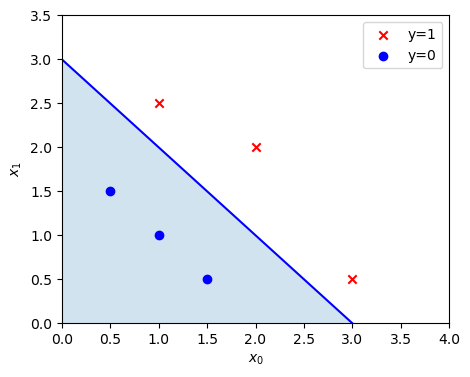

In [11]:
# Choose values between 0 and 6
x0 = np.arange(0,6)

x1 = 3 - x0
fig,ax = plt.subplots(1,1,figsize=(5,4))
# Plot the decision boundary
ax.plot(x0,x1, c="b")
ax.axis([0, 4, 0, 3.5])

# Fill the region below the line
ax.fill_between(x0,x1, alpha=0.2)

# Plot the original data

plot_data(X,y,ax)
ax.set_ylabel(r'$x_1$')
ax.set_xlabel(r'$x_0$')
plt.show()

## Train a logistic regression model using scikit-learn

https://scikit-learn.org/0.16/modules/generated/sklearn.linear_model.LogisticRegression.html


- Create a Regression Object
- Call fit function
- Get predictions
- Get Score of model
- Get coefficients (w0, w1) and intercept(b)

In [13]:
from sklearn.linear_model import LogisticRegression



In [14]:
###########################################################################
# YOUR CODE HERE\
model = LogisticRegression()

In [15]:

model.fit(X, y)

c:\Users\priya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
predictions = model.predict(X)

print(predictions)
probabilities = model.predict_proba(X)

print(probabilities)

[0 0 0 1 1 1]
[[0.685 0.315]
 [0.667 0.333]
 [0.648 0.352]
 [0.322 0.678]
 [0.28  0.72 ]
 [0.399 0.601]]


In [17]:
score = model.score(X, y)

print("Accuracy:", score)
w = model.coef_
b = model.intercept_

print("Coefficients (w0, w1):", w)
print("Intercept (b):", b)

Accuracy: 1.0
Coefficients (w0, w1): [[0.904 0.736]]
Intercept (b): [-2.334]
